# US Retail Sales - Transformations & Stationarity

`01_data_and_eda.ipynb` confirmed the raw NSA series is strongly
non-stationary (ADF p=0.998) with both trend and seasonal structure. This
notebook works through the same transformation options as the original
energy-consumption tutorial that inspired this project, checking each one
with its own ADF test rather than assuming the same conclusions carry over
to a different dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/raw/fred_retail_sales.csv', parse_dates=['date'], index_col='date')
df.index.freq = pd.infer_freq(df.index)
series = df['retail_sales_nsa']
print(series.shape)


(414,)


In [2]:
def adf_report(s, label, verbose=True):
    s = s.dropna()
    result = adfuller(s)
    if verbose:
        print(f'{label}: ADF={result[0]:.4f}  p-value={result[1]:.4f}  '
              f'stationary at 5%: {"Yes" if result[1] < 0.05 else "No"}')
    return result[1]

results = {}
results['raw'] = adf_report(series, 'Raw series')


Raw series: ADF=1.6568  p-value=0.9980  stationary at 5%: No


# 1. Simple variance - stabilizing transforms (log, sqrt, Box)

In [3]:
log_series = np.log(series)
sqrt_series = np.sqrt(series)
bc_values, bc_lambda = boxcox(series)
boxcox_series = pd.Series(bc_values, index=series.index)

results['log'] = adf_report(log_series, 'Log transform')
results['sqrt'] = adf_report(sqrt_series, 'Sqrt transform')
results['boxcox'] = adf_report(boxcox_series, f'Box-Cox (lambda={bc_lambda:.3f})')


Log transform: ADF=-0.5151  p-value=0.8890  stationary at 5%: No
Sqrt transform: ADF=0.7152  p-value=0.9901  stationary at 5%: No
Box-Cox (lambda=0.050): ADF=-0.3858  p-value=0.9124  stationary at 5%: No


**Result:** none of these achieve stationarity on their own (all p-values
stay above 0.88). This matches the original tutorial's finding — these
transforms address changing *variance*, not the trend or seasonal
*structure*, so they were never going to be sufficient by themselves. They
remain useful as a first step before differencing, though (see Section 3).


# 2. Moving-average detrending (SMA, EWMA)

In [5]:
sma_12 = series.rolling(window=12).mean()
series_minus_sma = (series - sma_12).dropna()

ewma_12 = series.ewm(span=12).mean()
series_minus_ewma = (series - ewma_12).dropna()

results['sma_detrend'] = adf_report(series_minus_sma, 'Series minus 12mo SMA')
results['ewma_detrend'] = adf_report(series_minus_ewma, 'Series minus 12mo EWMA')

print(f'\nRows lost to SMA(12): {sma_12.isna().sum()} (first {sma_12.isna().sum()} months, from the rolling window)')


Series minus 12mo SMA: ADF=-3.8467  p-value=0.0025  stationary at 5%: Yes
Series minus 12mo EWMA: ADF=-3.3893  p-value=0.0113  stationary at 5%: Yes

Rows lost to SMA(12): 11 (first 11 months, from the rolling window)


**Result — notably different from the original tutorial:** on this
retail sales series, **both** SMA and EWMA detrending achieve stationarity
(SMA: p≈0.003, EWMA: p≈0.011), whereas the original energy-consumption
tutorial reported EWMA *failing* to reach stationarity (p≈0.05) while SMA
succeeded. This is a useful reminder not to assume a conclusion from one
dataset transfers directly to another — the same technique can behave
differently depending on the series' actual trend/seasonality shape, and
it's worth re-checking rather than copying a decision from a different
project.

SMA still has the same practical downside as before: it discards the first
11 months of data (no rolling value until a full 12-month window is
available), while EWMA preserves the full series length. Since both are
statistically valid options here, EWMA is the more data-efficient choice if
this route were used — but see Section 3 for why we ultimately use
differencing instead.

# 3. Log transform + differencing

In [6]:
log_diff1 = log_series.diff().dropna()
results['log_diff1'] = adf_report(log_diff1, 'Log + 1st difference (trend removal)')

log_diff1_diff12 = log_diff1.diff(12).dropna()
results['log_diff1_diff12'] = adf_report(log_diff1_diff12, 'Log + 1st diff + seasonal diff(12)')


Log + 1st difference (trend removal): ADF=-4.3654  p-value=0.0003  stationary at 5%: Yes
Log + 1st diff + seasonal diff(12): ADF=-7.0713  p-value=0.0000  stationary at 5%: Yes


**Result:** log transform followed by a first difference already
achieves strong stationarity (p=0.0003) — this alone removes the trend.
Adding a seasonal (lag-12) difference on top pushes this even further
(p≈0.00000, ADF statistic -7.07), and — importantly — this combination
directly matches what the ACF/PACF plots in the previous notebook predicted:
the slow-decaying ACF pointed to a trend/unit-root problem (fixed by the
first difference), while the PACF spikes at lags 12-13 pointed to leftover
seasonal structure at a 12-month period (fixed by the seasonal difference).


# 4. Summary of all approaches tested

In [8]:
summary_df = pd.DataFrame({
    'transform': list(results.keys()),
    'p_value': list(results.values()),
}).sort_values('p_value')
summary_df['stationary_at_5pct'] = summary_df['p_value'] < 0.05
summary_df


,transform,p_value,stationary_at_5pct
7,log_diff1_diff12,4.928156e-10,True
6,log_diff1,3.415754e-04,True
4,sma_detrend,2.463907e-03,True
5,ewma_detrend,1.132829e-02,True
1,log,8.890441e-01,False
3,boxcox,9.124487e-01,False
2,sqrt,9.901373e-01,False
0,raw,9.980185e-01,False


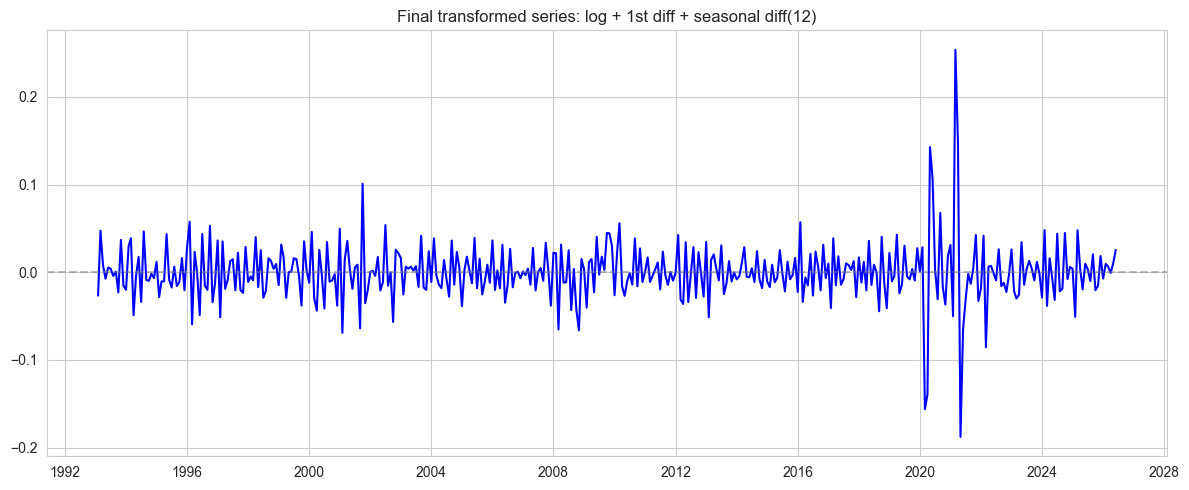

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log_diff1_diff12.index, log_diff1_diff12, color='BLUE')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Final transformed series: log + 1st diff + seasonal diff(12)')
plt.tight_layout()
plt.show()


# Conclusion

**Chosen transform: log transform → first difference → seasonal (lag-12)
difference**, matching the original tutorial's approach and confirmed here
independently via ADF testing at each step (not just copied from the
previous project). Two working alternatives exist (SMA and EWMA
detrending), but the log+difference route is preferred because it
integrates naturally into a SARIMA model's own differencing terms (`d` and
`D`) — rather than requiring us to manually detrend, forecast, and then
add the trend back — which is where this project is headed next.

**Next:** `03_sarima_forecasting.ipynb` fits a SARIMA model directly on the
log-transformed series and lets `auto_arima` search the `(d, D)` space
rather than fixing `d=1, D=1` from this notebook's manual differencing.
Note this may not exactly match what we found here — `auto_arima` is free
to substitute a seasonal AR/MA term for an explicit seasonal difference if
that scores better by AIC, which is a different (but not contradictory) way
of handling the same seasonal structure.